In [231]:
import yfinance as yf
import pandas as pd
from tabulate import tabulate
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
np.random.seed(42)

In [232]:
symbol_Apple='AAPL'
symbol_JPMorgan='JPM'
symbol_Exxon='XOM'
symbol_JohnsonNjohnsoN='JNJ'
symbol_Microsoft='MSFT'
symbol_Goldman='GS'
start_date='2020-01-01'
end_date='2025-01-01'
tickers=[symbol_Apple,symbol_JPMorgan,symbol_Exxon,symbol_JohnsonNjohnsoN,symbol_Microsoft,symbol_Goldman]
data = yf.download(tickers, start='2020-01-01', end='2025-01-01', auto_adjust=True)
prices = data['Close']

[*********************100%***********************]  6 of 6 completed


In [233]:
prices

Ticker,AAPL,GS,JNJ,JPM,MSFT,XOM
Date,,,,,,
2020-01-02,72.271553,200.251297,121.338493,117.899185,151.544250,52.606400
2020-01-03,71.568932,197.909668,119.933723,116.343361,149.657242,52.183472
2020-01-06,72.139198,199.935059,119.784050,116.250862,150.044067,52.584141
2020-01-07,71.799911,201.251190,120.515564,114.274498,148.676025,52.153793
2020-01-08,72.954933,203.191147,120.498962,115.165977,151.044189,51.367290
...,...,...,...,...,...,...
2024-12-24,256.339752,562.894409,139.277847,233.964600,433.363525,100.614822
2024-12-26,257.153839,561.387695,139.019989,234.766006,432.160126,100.699936
2024-12-27,253.748535,556.510132,138.513870,232.863861,424.682983,100.690483


In [234]:
prev_day=prices.shift(1)
daily_return=(prices-prev_day)/prev_day
daily_return=daily_return.dropna()


In [235]:
daily_return

Ticker,AAPL,GS,JNJ,JPM,MSFT,XOM
Date,,,,,,
2020-01-03,-0.009722,-0.011693,-0.011577,-0.013196,-0.012452,-0.008039
2020-01-06,0.007968,0.010234,-0.001248,-0.000795,0.002585,0.007678
2020-01-07,-0.004703,0.006583,0.006107,-0.017001,-0.009118,-0.008184
2020-01-08,0.016087,0.009639,-0.000138,0.007801,0.015928,-0.015080
2020-01-09,0.021241,0.020357,0.002966,0.003651,0.012493,0.007656
...,...,...,...,...,...,...
2024-12-24,0.011478,0.021041,0.003993,0.016444,0.009374,0.000941
2024-12-26,0.003176,-0.002677,-0.001851,0.003425,-0.002777,0.000846
2024-12-27,-0.013242,-0.008688,-0.003641,-0.008102,-0.017302,-0.000094


In [236]:
def monte_carlo(port_returns,confidence_lvl,num_simulation):
  mean=port_returns.mean()
  std=port_returns.std()
  simu_returns=np.random.normal(mean,std,num_simulation)
  losses=-simu_returns
  var_95=np.percentile(losses,(1-confidence_lvl)*100)
  var_99 = np.percentile(losses, 1)
  return var_95,var_99,simu_returns


In [237]:
num_sim=10000
conf=0.95
size_pf= len(tickers)
weights=[1/size_pf]*size_pf
port_return=daily_return.dot(weights)
var_95,var_99,simu=monte_carlo(port_return,0.95,num_sim)

print(f"VAR 95= {var_95} VAR 99= {var_99}")

VAR 95= -0.02425599191337967 VAR 99= -0.03399041689139505


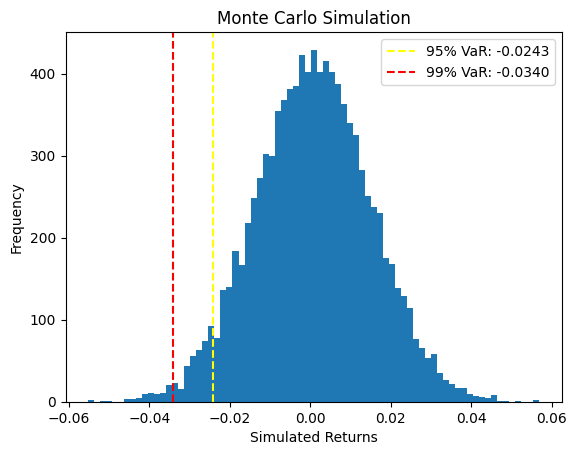

In [238]:
plt.hist(simu,bins=75)
plt.axvline(var_95,color="yellow",linestyle='--',label=f'95% VaR: {var_95:.4f}')
plt.axvline(var_99,color="red",linestyle='--',label=f'99% VaR: {var_99:.4f}')
plt.xlabel('Simulated Returns')
plt.ylabel('Frequency')
plt.title('Monte Carlo Simulation')
plt.legend()
plt.show()

In [239]:
corr_mat= daily_return.corr(numeric_only=True)
corr_mat

Ticker,AAPL,GS,JNJ,JPM,MSFT,XOM
Ticker,,,,,,
AAPL,1.000000,0.464456,0.374234,0.410425,0.748327,0.281849
GS,0.464456,1.000000,0.385257,0.828427,0.470663,0.542983
JNJ,0.374234,0.385257,1.000000,0.410896,0.379001,0.300596
JPM,0.410425,0.828427,0.410896,1.000000,0.421272,0.567948
MSFT,0.748327,0.470663,0.379001,0.421272,1.000000,0.242111
XOM,0.281849,0.542983,0.300596,0.567948,0.242111,1.000000


<Axes: xlabel='Ticker', ylabel='Ticker'>

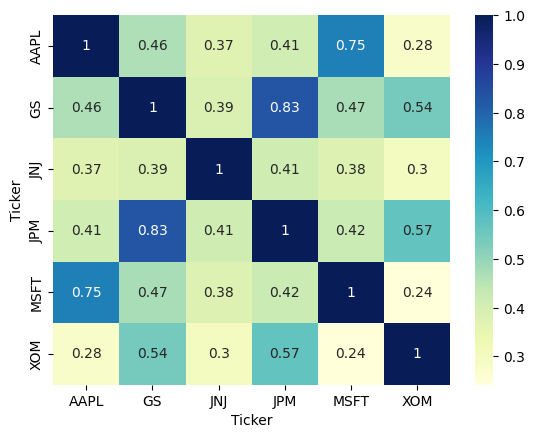

In [240]:
sns.heatmap(corr_mat,cmap="YlGnBu",annot=True)

In [241]:
daily_return

Ticker,AAPL,GS,JNJ,JPM,MSFT,XOM
Date,,,,,,
2020-01-03,-0.009722,-0.011693,-0.011577,-0.013196,-0.012452,-0.008039
2020-01-06,0.007968,0.010234,-0.001248,-0.000795,0.002585,0.007678
2020-01-07,-0.004703,0.006583,0.006107,-0.017001,-0.009118,-0.008184
2020-01-08,0.016087,0.009639,-0.000138,0.007801,0.015928,-0.015080
2020-01-09,0.021241,0.020357,0.002966,0.003651,0.012493,0.007656
...,...,...,...,...,...,...
2024-12-24,0.011478,0.021041,0.003993,0.016444,0.009374,0.000941
2024-12-26,0.003176,-0.002677,-0.001851,0.003425,-0.002777,0.000846
2024-12-27,-0.013242,-0.008688,-0.003641,-0.008102,-0.017302,-0.000094


In [242]:
rolling_vol = daily_return.rolling(window=30).std() * np.sqrt(252)

In [243]:
rolling_vol=rolling_vol.dropna()
rolling_vol

Ticker,AAPL,GS,JNJ,JPM,MSFT,XOM
Date,,,,,,
2020-02-14,0.262182,0.191828,0.101383,0.178378,0.229762,0.233834
2020-02-18,0.266897,0.194823,0.096962,0.178405,0.224212,0.234814
2020-02-19,0.268707,0.199254,0.096982,0.183107,0.224166,0.234815
2020-02-20,0.270526,0.206507,0.096817,0.175974,0.228359,0.234787
2020-02-21,0.276934,0.205790,0.100773,0.178260,0.249947,0.233832
...,...,...,...,...,...,...
2024-12-24,0.136781,0.215122,0.151030,0.178252,0.192191,0.157127
2024-12-26,0.136131,0.210258,0.145301,0.178449,0.190131,0.157504
2024-12-27,0.145894,0.211382,0.144601,0.179183,0.197194,0.153025


Text(0.5, 1.0, '30-Day Rolling Volatility')

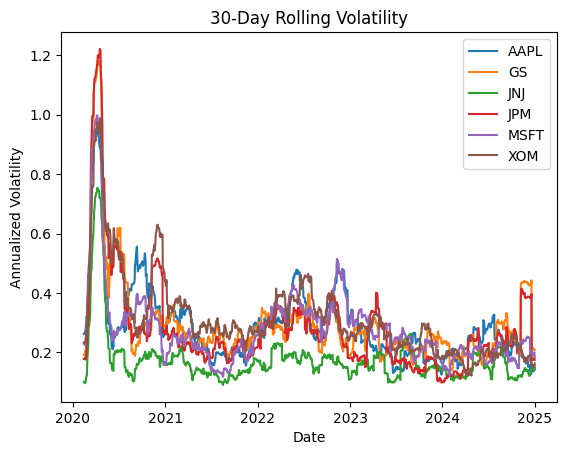

In [244]:
plt.plot(rolling_vol.index,rolling_vol)
plt.legend(daily_return.columns)
plt.xlabel('Date')
plt.ylabel('Annualized Volatility')
plt.title('30-Day Rolling Volatility')

In [245]:
sharpe={}
for col in daily_return:
  vol=(daily_return[col].std()*pow(252,0.5))
  sharpe[col]=(daily_return[col].mean()*252-0.04)/vol
sharpe=pd.Series(sharpe)
sharpe

,0
AAPL,0.814088
GS,0.659450
JNJ,0.026420
JPM,0.454798
MSFT,0.685082
XOM,0.440058


In [246]:
port_vol=port_return.std()*pow(252,0.5)
port_ann_return=port_return.mean()*252
portfolio_sharpe = (port_ann_return - 0.04) / port_vol
sharpe['Portfolio']=portfolio_sharpe
print(sharpe)

AAPL         0.814088
GS           0.659450
JNJ          0.026420
JPM          0.454798
MSFT         0.685082
XOM          0.440058
Portfolio    0.728056
dtype: float64


<BarContainer object of 7 artists>

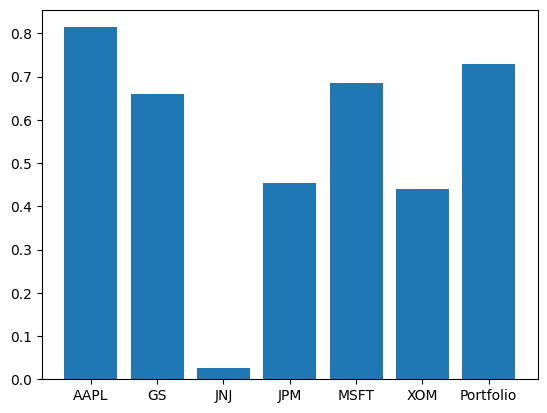

In [247]:
plt.bar(sharpe.index,sharpe)

In [248]:
port_sim=[]
i=0
cov_matr=daily_return.cov()*252
for i in range(10000):
  weights= np.random.random(6)
  weights=weights/weights.sum()
  annual_ret=weights.dot(daily_return.mean())*252
  annual_volatility=np.sqrt(weights@cov_matr@weights)
  sharpe=(annual_ret-0.04)/annual_volatility
  port_sim.append((weights,annual_ret,annual_volatility,sharpe))

In [249]:
port_sim_df=pd.DataFrame(port_sim,columns=['Weights','Return','Volatility','Sharpe'])
port_sim_df.shape

(10000, 4)

In [250]:
port_sim_df.head()

,Weights,Return,Volatility,Sharpe
0,"[0.26227279459857034, 0.08410489311821549, 0.0...",0.243496,0.254461,0.799714
1,"[0.10733310329297285, 0.23994304821906856, 0.0...",0.218001,0.243724,0.730338
2,"[0.20663252516125943, 0.2120064114995776, 0.11...",0.219395,0.233597,0.767969
3,"[0.1969207551959535, 0.05323817701524506, 0.21...",0.195199,0.217094,0.714894
4,"[0.14096937920705133, 0.22283213078506103, 0.1...",0.194198,0.231266,0.666754


In [251]:
optimal=port_sim_df.loc[port_sim_df['Sharpe'].idxmax()]
print(optimal)

Weights       [0.5870561335049888, 0.26128909256116434, 0.02...
Return                                                 0.272542
Volatility                                             0.267068
Sharpe                                                 0.870722
Name: 5058, dtype: object


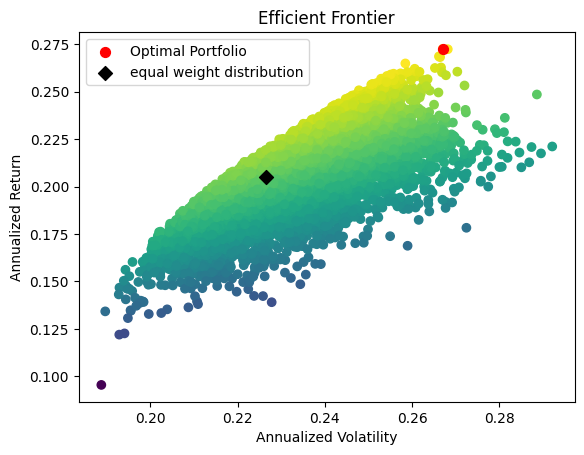

In [252]:
plt.scatter(x=port_sim_df['Volatility'],y=port_sim_df['Return'],c=port_sim_df['Sharpe'])
plt.scatter(optimal['Volatility'],optimal['Return'],marker='.',color='red',s=200,label='Optimal Portfolio')
plt.scatter(port_vol,port_ann_return,marker='D',color='black',s=50,label="equal weight distribution")
plt.xlabel('Annualized Volatility')
plt.ylabel('Annualized Return')
plt.title('Efficient Frontier')
plt.legend()
plt.show()

In [253]:
print(dict(zip(tickers,optimal['Weights'])))

{'AAPL': np.float64(0.5870561335049888), 'JPM': np.float64(0.26128909256116434), 'XOM': np.float64(0.0221223577495322), 'JNJ': np.float64(0.006858409774323904), 'MSFT': np.float64(0.07629141914741525), 'GS': np.float64(0.046382587262575325)}


In [254]:
port_ret_feat=pd.DataFrame({})
port_ret_feat['5 day mean']=port_return.rolling(5).mean()
port_ret_feat['20 day mean']=port_return.rolling(20).mean()
port_ret_feat['5 day std']=port_return.rolling(5).std()
port_ret_feat['20 day std']=port_return.rolling(20).std()
port_ret_feat['prev_day ret']=port_return.shift(1)
port_ret_feat=port_ret_feat.dropna()

In [255]:
port_ret_feat.head()

,5 day mean,20 day mean,5 day std,20 day std,prev_day ret
Date,,,,,
2020-01-31,-0.002544,-0.000477,0.017892,0.010436,0.010873
2020-02-03,0.001190,0.000253,0.016488,0.010160,-0.027055
2020-02-04,0.001231,0.000779,0.016531,0.010647,0.003487
2020-02-05,0.003630,0.001794,0.017837,0.011087,0.014932
2020-02-06,0.001652,0.001558,0.017375,0.011050,0.015913


In [256]:
threshold=port_return.quantile(0.25)
labels=(port_return < threshold).astype(int)
labels=labels.loc[port_ret_feat.index]

In [257]:
labels.value_counts()

,count
0,928
1,310


In [258]:
X=port_ret_feat
y=labels
split=int(len(X)*0.8)
X_train,X_test=X.iloc[:split],X.iloc[split:]
y_train,y_test=y.iloc[:split],y.iloc[split:]
print(X_train.shape,X_test.shape)

(990, 5) (248, 5)


In [259]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100,max_depth=5,min_samples_split=10,class_weight='balanced',random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=5,
                       min_samples_split=10, random_state=42)

In [260]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred=rf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.81      0.86       209
           1       0.35      0.56      0.44        39

    accuracy                           0.77       248
   macro avg       0.63      0.69      0.65       248
weighted avg       0.82      0.77      0.79       248



In [261]:
print(confusion_matrix(y_test, y_pred))

[[169  40]
 [ 17  22]]


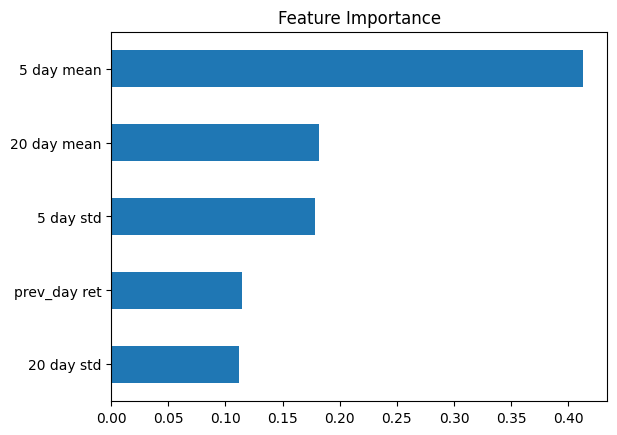

In [262]:
importance=pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title('Feature Importance')
plt.show()